# Angular Power Spectra: Galaxy Auto & CMB Lensing × Galaxy Cross
### GR vs f(R) Modified Gravity
---
This notebook computes the angular power spectra $C_\ell^{gg}$ (galaxy auto) and $C_\ell^{\kappa g}$ (CMB lensing × galaxy cross) using:
- The **Limber approximation** with standard line-of-sight kernels
- **BACCO** nonlinear matter power spectrum emulator
- **EMANTIS** f(R) gravity boost emulator
- Formalism following [Bianchini et al. (2015)](https://arxiv.org/pdf/1410.4502)

**Execution order:** Run cells top-to-bottom. The final cell runs validation checks.


In [1]:
pip install -q baccoemu emantis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 5.9 MB/s eta 0:00:00


## 1. Imports & Suppression of Verbose Output

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import os
from contextlib import redirect_stdout, redirect_stderr
from scipy.interpolate import interp1d
from scipy.integrate import simpson, quad

import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

print("All imports successful.")
print(f"NumPy  : {np.__version__}")
print(f"baccoemu available: {baccoemu is not None}")


All imports successful.
NumPy  : 2.0.2
baccoemu available: True


## 2. Configuration
All run parameters are centralised in the `Config` class.  
Edit values here to change the cosmology, redshift range, multipole range, or f(R) parameters.


In [3]:
class Config:
    # ── Cosmological Parameters ────────────────────────────────────────────────
    COSMO_PARAMS = {
        "Omega_m":  0.315,   # Total matter density parameter
        "Omega_b":  0.05,    # Baryon density parameter
        "h":        0.67,    # Reduced Hubble constant (H0 = 100h km/s/Mpc)
        "n_s":      0.96,    # Primordial scalar spectral index
        "sigma8":   0.83,    # RMS matter fluctuation amplitude at 8 Mpc/h
        "M_nu":     0.0,     # Sum of neutrino masses (eV)
        "w0":      -1.0,     # Dark energy equation of state today
        "wa":       0.0,     # Time variation of dark energy equation of state
        "aexp":     1.0      # Scale factor (1.0 = present day)
    }

    TRANSFER_FUNCTION = "boltzmann_camb"  # Boltzmann solver for transfer function

    c = 299792.458  # Speed of light [km/s]

    # ── Redshift Grid ──────────────────────────────────────────────────────────
    Z_MIN       = 0.01   # Minimum redshift
    Z_MAX       = 1.5    # Maximum redshift
    N_Z         = 500    # Number of redshift sampling points
    Z0_GALAXY   = 0.3    # Characteristic galaxy redshift parameter

    # ── Multipole Range ────────────────────────────────────────────────────────
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL   = 50

    # ── Galaxy & Magnification Bias ───────────────────────────────────────────
    BIAS_B0 = 2.0    # Linear galaxy bias
    alpha   = 2.225  # Magnification bias (Karim et al., α ≃ 2.225)

    # ── f(R) Parameters ───────────────────────────────────────────────────────
    FR_VALUES = [4, 5, 6]  # log10|fR0| values to compute

    # ── BACCO k-grid ──────────────────────────────────────────────────────────
    BACCO_K_MIN    = -2    # Minimum log10(k)
    BACCO_K_MAX    = None  # None → use emulator maximum
    BACCO_N_K      = 200
    EMANTIS_VERBOSE = False

    FIGURE_SIZE = (14, 10)

    # ── k-clipping safety ─────────────────────────────────────────────────────
    K_MIN_SAFETY     = 1.1
    K_MAX_SAFETY     = 0.9
    K_CLIP_THRESHOLD = 0.05

# ── Quick summary ──────────────────────────────────────────────────────────────
print("Configuration loaded.")
print(f"  Cosmology : Ωm={Config.COSMO_PARAMS['Omega_m']}, "
      f"h={Config.COSMO_PARAMS['h']}, σ8={Config.COSMO_PARAMS['sigma8']}")
print(f"  Redshift  : z ∈ [{Config.Z_MIN}, {Config.Z_MAX}], N_z={Config.N_Z}")
print(f"  Multipoles: ℓ ∈ [{Config.ELL_MIN}, {Config.ELL_MAX}], N_ℓ={Config.N_ELL}")
print(f"  f(R) log10|fR0| values: {Config.FR_VALUES}")
print(f"  Bias b0={Config.BIAS_B0},  α_mag={Config.alpha}")


Configuration loaded.
  Cosmology : Ωm=0.315, h=0.67, σ8=0.83
  Redshift  : z ∈ [0.01, 1.5], N_z=500
  Multipoles: ℓ ∈ [10, 2000], N_ℓ=50
  f(R) log10|fR0| values: [4, 5, 6]
  Bias b0=2.0,  α_mag=2.225


## 3. Core Cosmological Functions

Implements the fundamental cosmological building blocks used throughout:

| Function | Description | Reference |
|---|---|---|
| `hubble_function` | $H(z)$ for flat wCDM | Lin et al. (2009) Eq. 1 |
| `comoving_distance_proper` | $\chi(z)$ via quadrature | Lahav et al. (2004) Eq. 146 |
| `growth_factor_D` | Normalized linear growth $D(z)/D(0)$ | Lahav et al. (2004) Eq. 66–67 |
| `cmb_lensing_kernel` | $W^\kappa(z)$ | Bianchini et al. (2015) Eqs. 3–4 |
| `galaxy_lensing_kernel` | $W^g(z)$ incl. magnification | Bianchini et al. (2015) Eq. 6 |
| `bias_function` | Scale-dependent bias $b(z)$ | Karim et al. (2025) Eq. 4.7 |


In [4]:
# Convenience aliases
H0     = Config.COSMO_PARAMS["h"] * 100.0
Om_m   = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m  # flat ΛCDM

# ── Hubble function H(z) ──────────────────────────────────────────────────────
def hubble_function(z, H0, Om_m, Om_lambda):
    """H(z) for flat wCDM cosmology [km/s/Mpc]."""
    return H0 * np.sqrt(
        Om_m * (1 + z)**3
        + (1 - Om_m - Om_lambda) * (1 + z)**2
        + Om_lambda
    )

# ── Comoving distance ─────────────────────────────────────────────────────────
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    """Comoving distance χ(z) [Mpc/h] via numerical quadrature."""
    def integrand(zp):
        return Config.c / hubble_function(zp, H0, Om_m, Om_lambda)
    if np.isscalar(z):
        return quad(integrand, 0, z)[0]
    return np.array([quad(integrand, 0, zv)[0] for zv in z])

# ── Ω(z) and λ(z) helpers ────────────────────────────────────────────────────
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    den = Om_m*(1+z)**3 + (1-Om_m-Om_lambda)*(1+z)**2 + Om_lambda
    return Om_m * (1+z)**3 / den

def compute_lambda_z(z, H0, Om_m, Om_lambda):
    den = Om_m*(1+z)**3 + (1-Om_m-Om_lambda)*(1+z)**2 + Om_lambda
    return Om_lambda / den

# ── Carroll–Press–Turner growth function g(z) ────────────────────────────────
def growth_function_g(z, H0, Om_m, Om_lambda):
    """Carroll–Press–Turner (1992) fitting formula for g(z)."""
    Oz = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lz = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Oz**(4/7) - lz + (1 + Oz/2)*(1 + lz/70)
    return (5 * Oz / 2) / den

# ── Normalised linear growth factor D(z) ────────────────────────────────────
def growth_factor_D(z, H0, Om_m, Om_lambda):
    """D(z) normalised so D(0)=1."""
    g0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
    D0_raw = g0  # (1+0)=1
    if np.isscalar(z):
        gz = growth_function_g(z, H0, Om_m, Om_lambda)
        return (gz / (1.0 + z)) / D0_raw
    gz = np.array([growth_function_g(zv, H0, Om_m, Om_lambda) for zv in z])
    return (gz / (1.0 + z)) / D0_raw

# ── CMB lensing kernel W_κ(z) ────────────────────────────────────────────────
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    """
    CMB lensing weight function W^κ(z).
    Includes 1/H(z) factor for consistency with the dz-basis Limber integral.
    Bianchini et al. (2015) Eqs. (3)–(4).
    """
    Hz = hubble_function(z, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0**2) / (2 * Config.c * Hz)
    chi_z    = comoving_distance_proper(z,      H0, Om_m, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
    return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star

# ── Galaxy kernel W_g(z) ─────────────────────────────────────────────────────
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    """
    Full galaxy LOS kernel W^g(z) = b(z)dN/dz + magnification term.
    Bianchini et al. (2015) Eq. (6); Karim et al. (2025) Eqs. (4.3)–(4.4).
    """
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    Hz    = hubble_function(z, H0, Om_m, Om_lambda)

    def integrand(zp):
        chi_zp = comoving_distance_proper(zp, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_zp) * (Config.alpha - 1) * dN_dz_func(zp)

    integral, _ = quad(integrand, z, 10.0)
    mu_pref = (3 * Om_m * H0**2) / (2 * Config.c * Hz) * (1 + z) * chi_z
    return bias_term + mu_pref * integral

# ── Scale-dependent galaxy bias b(z) ─────────────────────────────────────────
def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    """b(z) = b0 / D*(z),  Karim et al. (2025) Eq. (4.7)."""
    Dz = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D0 = growth_factor_D(0, H0, Omega_m, Omega_lambda)
    return b0 / (Dz / D0 + 1e-30)

print("Core cosmological functions defined.")


Core cosmological functions defined.


### 3.1 Sanity-Check Plot — Cosmological Functions

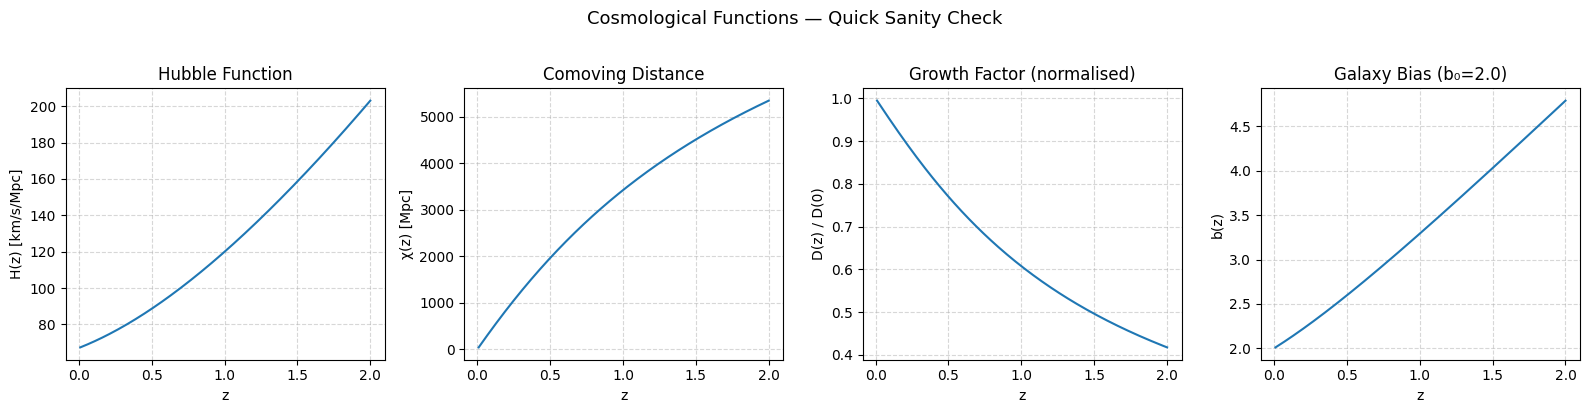

H(z=0)  = 67.00 km/s/Mpc  (expected ≈ 67.0)
χ(z=0)  = 4.47 Mpc  (expected ≈ 0)
D(z=0)  = 0.9995  (expected ≈ 1.0)


In [5]:
z_test = np.linspace(0.01, 2.0, 200)

H_test   = hubble_function(z_test, H0, Om_m, Om_lambda)
chi_test = comoving_distance_proper(z_test, H0, Om_m, Om_lambda)
D_test   = growth_factor_D(z_test, H0, Om_m, Om_lambda)
b_test   = bias_function(z_test, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(z_test, H_test)
axes[0].set(xlabel='z', ylabel='H(z) [km/s/Mpc]', title='Hubble Function')
axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(z_test, chi_test)
axes[1].set(xlabel='z', ylabel='χ(z) [Mpc]', title='Comoving Distance')
axes[1].grid(True, ls='--', alpha=0.5)

axes[2].plot(z_test, D_test)
axes[2].set(xlabel='z', ylabel='D(z) / D(0)', title='Growth Factor (normalised)')
axes[2].grid(True, ls='--', alpha=0.5)

axes[3].plot(z_test, b_test)
axes[3].set(xlabel='z', ylabel='b(z)', title=f'Galaxy Bias (b₀={Config.BIAS_B0})')
axes[3].grid(True, ls='--', alpha=0.5)

plt.suptitle('Cosmological Functions — Quick Sanity Check', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"H(z=0)  = {hubble_function(0, H0, Om_m, Om_lambda):.2f} km/s/Mpc  (expected ≈ {H0:.1f})")
print(f"χ(z=0)  = {comoving_distance_proper(0.001, H0, Om_m, Om_lambda):.2f} Mpc  (expected ≈ 0)")
print(f"D(z=0)  = {growth_factor_D(0.001, H0, Om_m, Om_lambda):.4f}  (expected ≈ 1.0)")


## 4. Power Spectrum Utilities (BACCO / EMANTIS)

- **BACCO** provides nonlinear $P(k, z)$ for GR.  
- **EMANTIS** provides the f(R) boost factor $B(k, z) = P^{f(R)}(k,z) / P^{\rm GR}(k,z)$.  
- A log–log cubic interpolator converts discrete emulator output into a smooth $P(k)$ callable at any $k = \ell/\chi(z)$.


In [6]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    """Initialise BACCO nonlinear matter power-spectrum emulator."""
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())
            k = np.logspace(k_min, k_max, num=n_k)
    return emulator, k


def get_bacco_nonlinear_pk(emulator, params, k, aexp=1.0):
    """Return nonlinear P(k) at scale factor `aexp`."""
    params_bacco = {
        "omega_cold":    params["Omega_m"] - params["Omega_b"],
        "sigma8_cold":   params["sigma8"],
        "omega_baryon":  params["Omega_b"],
        "ns":            params["n_s"],
        "hubble":        params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0":            params.get("w0", -1.0),
        "wa":            params.get("wa", 0.0),
        "expfactor":     aexp
    }
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)
    return pk_nl


def initialize_emantis_emulator(verbose=False):
    """Initialise EMANTIS f(R) boost emulator."""
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    """Return the f(R) boost factor B(k) for a given log10|fR0|."""
    params_emantis = {
        "Omega_m":      params["Omega_m"],
        "Omega_b":      params["Omega_b"],
        "h":            params["h"],
        "n_s":          params["n_s"],
        "sigma8_lcdm":  params["sigma8"],
        "logfR0":       logfR0
    }
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)


def create_power_spectrum_interpolator(k, pk):
    """Log–log cubic spline interpolator for P(k), stable across power-law regimes."""
    return interp1d(
        np.log(k), np.log(pk + 1e-50),
        kind='cubic', bounds_error=False, fill_value='extrapolate'
    )


def build_pk_interpolators_over_z(emulator, params, k, z_grid):
    """One BACCO nonlinear P(k,z) interpolator per redshift slice."""
    return [
        create_power_spectrum_interpolator(
            k, get_bacco_nonlinear_pk(emulator, params, k, aexp=1.0/(1+z))
        )
        for z in z_grid
    ]


def build_pk_interpolators_over_z_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    """One f(R) P(k,z) interpolator per redshift slice."""
    interps = []
    for z in z_grid:
        aexp   = 1.0 / (1.0 + z)
        pk_gr  = get_bacco_nonlinear_pk(emulator, params, k, aexp=aexp)
        boost  = compute_fR_boost(emantis_emu, params, logfR0, k, aexp=aexp)
        interps.append(create_power_spectrum_interpolator(k, pk_gr * boost))
    return interps


def check_k_bounds(k_vals, k_min, k_max, ell, label, threshold=0.05):
    """Clip k values to safe emulator bounds."""
    return np.clip(k_vals, k_min, k_max)

print("Power-spectrum utility functions defined.")


Power-spectrum utility functions defined.


## 5. Initialise Emulators

Load BACCO and EMANTIS.  This cell may take ~30 s on first run as emulator weights are read from disk.


In [7]:
print("Initialising BACCO emulator …")
bacco_emu, k = initialize_bacco_emulator(
    Config.COSMO_PARAMS,
    k_min=Config.BACCO_K_MIN,
    k_max=Config.BACCO_K_MAX,
    n_k=Config.BACCO_N_K,
    verbose=Config.EMANTIS_VERBOSE
)
print(f"  k grid: {k.min():.4f} – {k.max():.2f} h/Mpc  ({len(k)} points)")

print("Initialising EMANTIS emulator …")
emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)
print("  EMANTIS ready.")

# Compute GR P(k) at z=0 for a quick visual check
pk_nl_gr_z0 = get_bacco_nonlinear_pk(bacco_emu, Config.COSMO_PARAMS, k, aexp=1.0)
print(f"\nP(k) at z=0: min={pk_nl_gr_z0.min():.3e}, max={pk_nl_gr_z0.max():.3e} (Mpc/h)³")


Initialising BACCO emulator …


100% (358400 of 358400) |################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2304000 of 2304000) |##############| Elapsed Time: 0:00:01 Time:  0:00:01
100% (2785280 of 2785280) |##############| Elapsed Time: 0:00:01 Time:  0:00:01
100% (2293760 of 2293760) |##############| Elapsed Time: 0:00:01 Time:  0:00:01


  k grid: 0.0100 – 4.90 h/Mpc  (200 points)
Initialising EMANTIS emulator …
  EMANTIS ready.

P(k) at z=0: min=4.127e+01, max=3.747e+04 (Mpc/h)³


### 5.1 Matter Power Spectrum and f(R) Boost Factors at z = 0

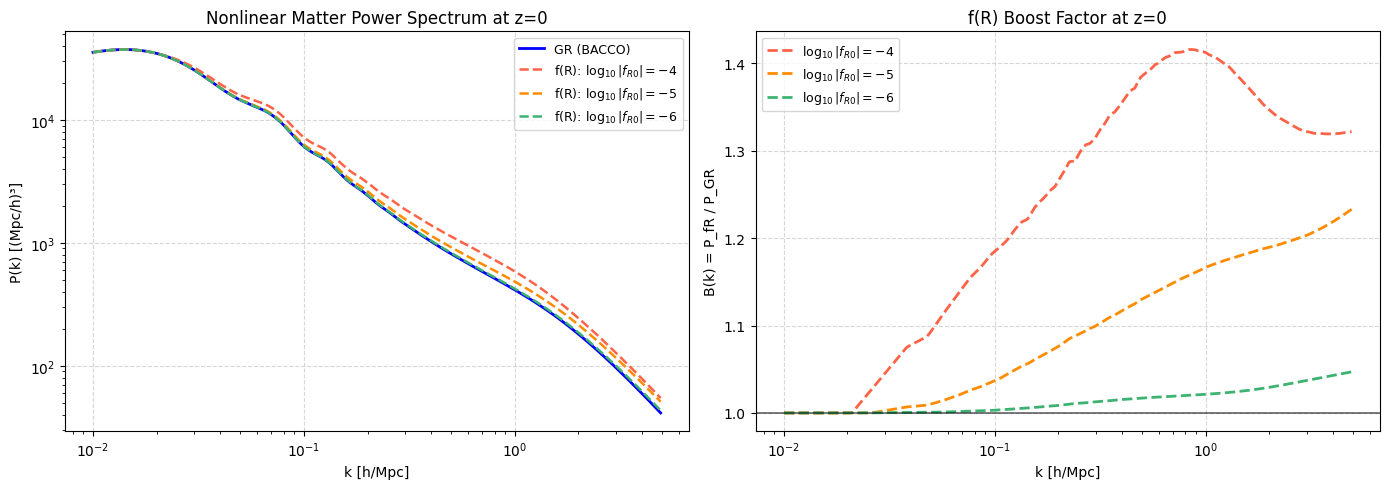

  log10|fR0|=-4: boost range [1.0000, 1.4159]
  log10|fR0|=-5: boost range [1.0000, 1.2331]
  log10|fR0|=-6: boost range [1.0000, 1.0470]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── P(k) GR ──────────────────────────────────────────────────────────────────
axes[0].loglog(k, pk_nl_gr_z0, 'b-', lw=2, label='GR (BACCO)')
colors = ['tomato', 'darkorange', 'mediumseagreen']
for logfR0, col in zip(Config.FR_VALUES, colors):
    boost_z0 = compute_fR_boost(emantis_emu, Config.COSMO_PARAMS, logfR0, k, aexp=1.0)
    axes[0].loglog(k, pk_nl_gr_z0 * boost_z0, '--', lw=1.8, color=col,
                   label=rf'f(R): $\log_{{10}}|f_{{R0}}|=-{logfR0}$')
axes[0].set(xlabel='k [h/Mpc]', ylabel='P(k) [(Mpc/h)³]',
            title='Nonlinear Matter Power Spectrum at z=0')
axes[0].legend(fontsize=9)
axes[0].grid(True, ls='--', alpha=0.5)

# ── Boost factors ────────────────────────────────────────────────────────────
for logfR0, col in zip(Config.FR_VALUES, colors):
    boost_z0 = compute_fR_boost(emantis_emu, Config.COSMO_PARAMS, logfR0, k, aexp=1.0)
    axes[1].semilogx(k, boost_z0, '--', lw=2, color=col,
                     label=rf'$\log_{{10}}|f_{{R0}}|=-{logfR0}$')
axes[1].axhline(1.0, color='k', lw=1.2, alpha=0.6, ls='-')
axes[1].set(xlabel='k [h/Mpc]', ylabel='B(k) = P_fR / P_GR',
            title='f(R) Boost Factor at z=0')
axes[1].legend(fontsize=9)
axes[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

for logfR0 in Config.FR_VALUES:
    b = compute_fR_boost(emantis_emu, Config.COSMO_PARAMS, logfR0, k, aexp=1.0)
    print(f"  log10|fR0|=-{logfR0}: boost range [{b.min():.4f}, {b.max():.4f}]")


## 6. Pre-compute Redshift-Dependent Quantities

This section builds:
- The normalised galaxy redshift distribution $n(z) \propto z^2 e^{-z/z_0}$
- The comoving distance grid $\chi(z)$, Hubble factor $H(z)$, growth factor $D(z)$
- The CMB lensing kernel $W^\kappa(z)$ at each redshift slice
- The full galaxy LOS kernel $W^g(z)$ including magnification bias


In [9]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

# ── Galaxy n(z) ───────────────────────────────────────────────────────────────
z0 = Config.Z0_GALAXY
_raw_nz   = 2.0 * z0 * (z_grid / z0)**2 * np.exp(-z_grid / z0)
_norm     = simpson(_raw_nz, z_grid)
dNdz      = _raw_nz / _norm
dNdz_func = interp1d(z_grid, dNdz, kind='linear', bounds_error=False, fill_value=0.0)

print(f"n(z) normalisation check: ∫n(z)dz = {simpson(dNdz, z_grid):.6f}  (expected 1.0)")

# ── Distance / H / growth grids ───────────────────────────────────────────────
print("Computing χ(z), H(z), D(z) on redshift grid …")
chi_vals = comoving_distance_proper(z_grid, H0, Om_m, Om_lambda)
H_vals   = hubble_function(z_grid, H0, Om_m, Om_lambda)
D_vals   = growth_factor_D(z_grid, H0, Om_m, Om_lambda)
D0       = growth_factor_D(0.0, H0, Om_m, Om_lambda)
print(f"  χ range : {chi_vals.min():.1f} – {chi_vals.max():.1f} Mpc")
print(f"  H range : {H_vals.min():.1f} – {H_vals.max():.1f} km/s/Mpc")
print(f"  D range : {D_vals.min():.4f} – {D_vals.max():.4f}")

# ── CMB lensing kernel ────────────────────────────────────────────────────────
z_star     = 1100.0
Wkappa_vals = cmb_lensing_kernel(z_grid, z_star, H0, Om_m, Om_lambda)
print(f"  W_κ peak ≈ {Wkappa_vals.max():.4e}  at z ≈ {z_grid[np.argmax(Wkappa_vals)]:.2f}")

# ── Galaxy kernel (includes magnification) ────────────────────────────────────
print("Computing full galaxy kernel W_g(z) (incl. magnification) …")
bias_func_local = lambda z: bias_function(z, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
Wg_vals = np.array([
    galaxy_lensing_kernel(z, z_grid, dNdz_func, bias_func_local, H0, Om_m, Om_lambda)
    for z in z_grid
])
print(f"  W_g range: [{Wg_vals.min():.4e}, {Wg_vals.max():.4e}]")


n(z) normalisation check: ∫n(z)dz = 1.000000  (expected 1.0)
Computing χ(z), H(z), D(z) on redshift grid …
  χ range : 44.6 – 4508.9 Mpc
  H range : 67.3 – 158.6 km/s/Mpc
  D range : 0.4963 – 0.9949
  W_κ peak ≈ 3.4100e-01  at z ≈ 1.50
Computing full galaxy kernel W_g(z) (incl. magnification) …
  W_g range: [9.7954e-03, 2.9288e+00]


### 6.1 Visualise Redshift Kernels

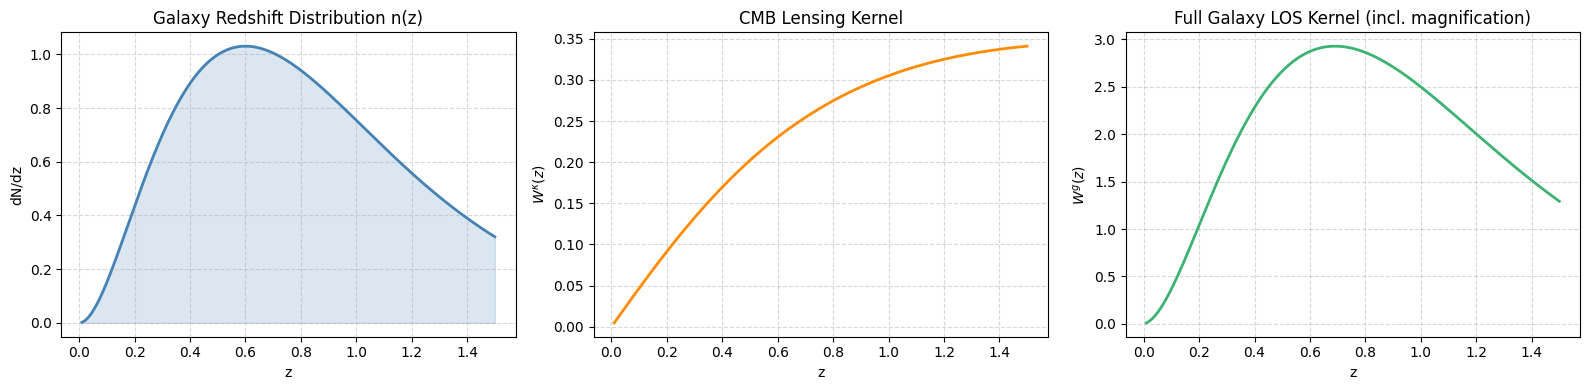

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(z_grid, dNdz, 'steelblue', lw=2)
axes[0].set(xlabel='z', ylabel='dN/dz', title='Galaxy Redshift Distribution n(z)')
axes[0].fill_between(z_grid, dNdz, alpha=0.2, color='steelblue')
axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(z_grid, Wkappa_vals, 'darkorange', lw=2)
axes[1].set(xlabel='z', ylabel=r'$W^\kappa(z)$', title='CMB Lensing Kernel')
axes[1].grid(True, ls='--', alpha=0.5)

axes[2].plot(z_grid, Wg_vals, 'mediumseagreen', lw=2)
axes[2].set(xlabel='z', ylabel=r'$W^g(z)$', title='Full Galaxy LOS Kernel (incl. magnification)')
axes[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Build P(k, z) Interpolators

Evaluates BACCO (and EMANTIS-boosted) $P(k)$ at every redshift slice and stores a log–log spline for each, ready to be evaluated at $k = (\ell + 1/2)/\chi(z)$ inside the Limber integral.


In [11]:
k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY
print(f"Safe k range: [{k_min_safe:.5f}, {k_max_safe:.3f}] h/Mpc")

print(f"Building GR P(k,z) interpolators for {len(z_grid)} redshift slices …")
pk_interp_gr_z = build_pk_interpolators_over_z(bacco_emu, Config.COSMO_PARAMS, k, z_grid)
print("  GR done.")

fr_pk_interps = {}
for logfR0_val in Config.FR_VALUES:
    print(f"Building f(R) P(k,z) interpolators for log10|fR0|=-{logfR0_val} …")
    fr_pk_interps[logfR0_val] = build_pk_interpolators_over_z_fr(
        bacco_emu, emantis_emu, Config.COSMO_PARAMS, logfR0_val, k, z_grid
    )
    print(f"  Done.")
print("\nAll P(k,z) interpolators ready.")


Safe k range: [0.01100, 4.413] h/Mpc
Building GR P(k,z) interpolators for 500 redshift slices …
  GR done.
Building f(R) P(k,z) interpolators for log10|fR0|=-4 …
  Done.
Building f(R) P(k,z) interpolators for log10|fR0|=-5 …
  Done.
Building f(R) P(k,z) interpolators for log10|fR0|=-6 …
  Done.

All P(k,z) interpolators ready.


### 7.1 P(k) at Selected Redshifts

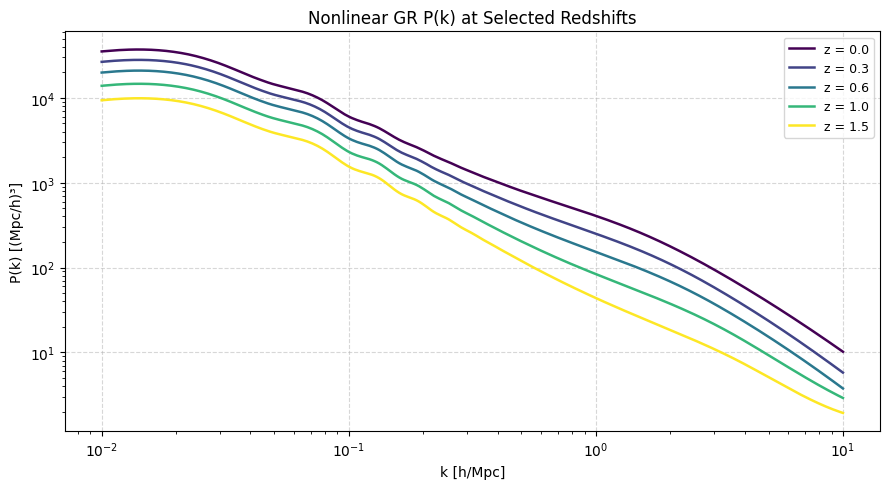

In [12]:
z_show = [0.0, 0.3, 0.6, 1.0, 1.5]
k_plot = np.logspace(-2, 1, 300)
z_indices = [np.argmin(np.abs(z_grid - zv)) for zv in z_show]

fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.cm.viridis
for idx, zv in zip(z_indices, z_show):
    logpk = pk_interp_gr_z[idx](np.log(k_plot))
    ax.loglog(k_plot, np.exp(logpk), color=cmap(zv / 1.5), lw=1.8, label=f'z = {zv}')

ax.set(xlabel='k [h/Mpc]', ylabel='P(k) [(Mpc/h)³]',
       title='Nonlinear GR P(k) at Selected Redshifts')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Limber Angular Power Spectra

The angular power spectrum is computed via the Limber approximation:

$$C_\ell^{AB} = \int dz\, \frac{H(z)}{c\,\chi^2(z)}\, W^A(z)\, W^B(z)\, P\!\left(k=\frac{\ell+\tfrac{1}{2}}{\chi(z)}, z\right)$$

Two spectra are computed:

| Spectrum | $W^A$ | $W^B$ | Eq. |
|---|---|---|---|
| $C_\ell^{gg}$ | $W^g$ | $W^g$ | Bianchini (2015) Eq. 8 |
| $C_\ell^{\kappa g}$ | $W^\kappa$ | $W^g$ | Bianchini (2015) Eq. 7 |


In [13]:
def compute_Cl_galaxy_auto(
    ell_array, pk_interp_list, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0, k_min=None, k_max=None
):
    """Galaxy auto-spectrum C_ℓ^{gg} via Limber integration."""
    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "Cgg") if k_min else k_vals
        try:
            P_kz = np.exp([pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))])
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wg_vals ** 2) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl


def compute_Cl_galaxy_cmb_cross(
    ell_array, pk_interp_list, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, c_light,
    H0, Om_m, Om_lambda, b0=2.0, k_min=None, k_max=None
):
    """Galaxy–CMB lensing cross-spectrum C_ℓ^{κg} via Limber integration."""
    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "Ckg") if k_min else k_vals
        try:
            P_kz = np.exp([pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))])
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wkappa_vals * Wg_vals) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl

print("Limber integration functions defined.")


Limber integration functions defined.


## 9. Compute Angular Power Spectra

In [14]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)
print(f"ℓ grid: {ell.min():.0f} – {ell.max():.0f}  ({len(ell)} points)")

# ── GR spectra ────────────────────────────────────────────────────────────────
print("\nComputing GR C_ℓ^{gg} …")
Cl_gg_gr = compute_Cl_galaxy_auto(
    ell, pk_interp_gr_z, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)
print(f"  C_ℓ^{{gg}} range: [{Cl_gg_gr.min():.3e}, {Cl_gg_gr.max():.3e}]")

print("Computing GR C_ℓ^{κg} …")
Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
    ell, pk_interp_gr_z, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)
print(f"  C_ℓ^{{κg}} range: [{Cl_kg_gr.min():.3e}, {Cl_kg_gr.max():.3e}]")

# ── f(R) spectra ──────────────────────────────────────────────────────────────
fr_results = {"gg": {}, "kg": {}}
for logfR0_val in Config.FR_VALUES:
    print(f"\nComputing f(R) spectra for log10|fR0|=-{logfR0_val} …")
    Cl_gg_fr = compute_Cl_galaxy_auto(
        ell, fr_pk_interps[logfR0_val], z_grid, Wg_vals,
        chi_vals, H_vals, D_vals, D0, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )
    Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
        ell, fr_pk_interps[logfR0_val], z_grid, Wg_vals,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )
    fr_results["gg"][logfR0_val] = Cl_gg_fr
    fr_results["kg"][logfR0_val] = Cl_kg_fr
    print(f"  C_ℓ^{{gg}} range: [{Cl_gg_fr.min():.3e}, {Cl_gg_fr.max():.3e}]")
    print(f"  C_ℓ^{{κg}} range: [{Cl_kg_fr.min():.3e}, {Cl_kg_fr.max():.3e}]")

print("\nAll spectra computed.")


ℓ grid: 10 – 2000  (50 points)

Computing GR C_ℓ^{gg} …
  C_ℓ^{gg} range: [6.831e-08, 9.193e-06]
Computing GR C_ℓ^{κg} …
  C_ℓ^{κg} range: [6.492e-09, 8.379e-07]

Computing f(R) spectra for log10|fR0|=-4 …
  C_ℓ^{gg} range: [8.899e-08, 9.200e-06]
  C_ℓ^{κg} range: [8.333e-09, 8.393e-07]

Computing f(R) spectra for log10|fR0|=-5 …
  C_ℓ^{gg} range: [7.548e-08, 9.193e-06]
  C_ℓ^{κg} range: [7.119e-09, 8.381e-07]

Computing f(R) spectra for log10|fR0|=-6 …
  C_ℓ^{gg} range: [6.929e-08, 9.195e-06]
  C_ℓ^{κg} range: [6.579e-09, 8.382e-07]

All spectra computed.


### 9.1 Tabular Summary at Selected Multipoles

In [15]:
import warnings
try:
    import pandas as pd
    _pandas = True
except ImportError:
    _pandas = False

ell_show = [10, 50, 100, 500, 1000, 2000]
ell_idx  = [np.argmin(np.abs(ell - lv)) for lv in ell_show]

rows = []
for idx in ell_idx:
    row = {"ell": f"{ell[idx]:.0f}", "Cl_gg_GR": f"{Cl_gg_gr[idx]:.3e}",
           "Cl_kg_GR": f"{Cl_kg_gr[idx]:.3e}"}
    for fv in Config.FR_VALUES:
        row[f"Cl_gg_fR{fv}"] = f"{fr_results['gg'][fv][idx]:.3e}"
        row[f"Cl_kg_fR{fv}"] = f"{fr_results['kg'][fv][idx]:.3e}"
    rows.append(row)

if _pandas:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df)
else:
    header = list(rows[0].keys())
    print("  ".join(f"{h:>14}" for h in header))
    for r in rows:
        print("  ".join(f"{r[h]:>14}" for h in header))


,ell,Cl_gg_GR,Cl_kg_GR,Cl_gg_fR4,Cl_kg_fR4,Cl_gg_fR5,Cl_kg_fR5,Cl_gg_fR6,Cl_kg_fR6
0,10,9.193e-06,8.379e-07,9.200e-06,8.393e-07,9.193e-06,8.381e-07,9.195e-06,8.382e-07
1,51,6.589e-06,6.118e-07,6.724e-06,6.234e-07,6.604e-06,6.132e-07,6.593e-06,6.123e-07
2,97,3.754e-06,3.650e-07,3.938e-06,3.804e-07,3.780e-06,3.673e-07,3.757e-06,3.653e-07
3,490,4.481e-07,4.529e-08,5.230e-07,5.200e-08,4.677e-07,4.700e-08,4.506e-07,4.551e-08
4,1045,1.541e-07,1.510e-08,1.924e-07,1.852e-08,1.659e-07,1.614e-08,1.557e-07,1.524e-08
5,2000,6.831e-08,6.492e-09,8.899e-08,8.333e-09,7.548e-08,7.119e-09,6.929e-08,6.579e-09


## 10. Full Results — Angular Power Spectra and f(R)/GR Ratios

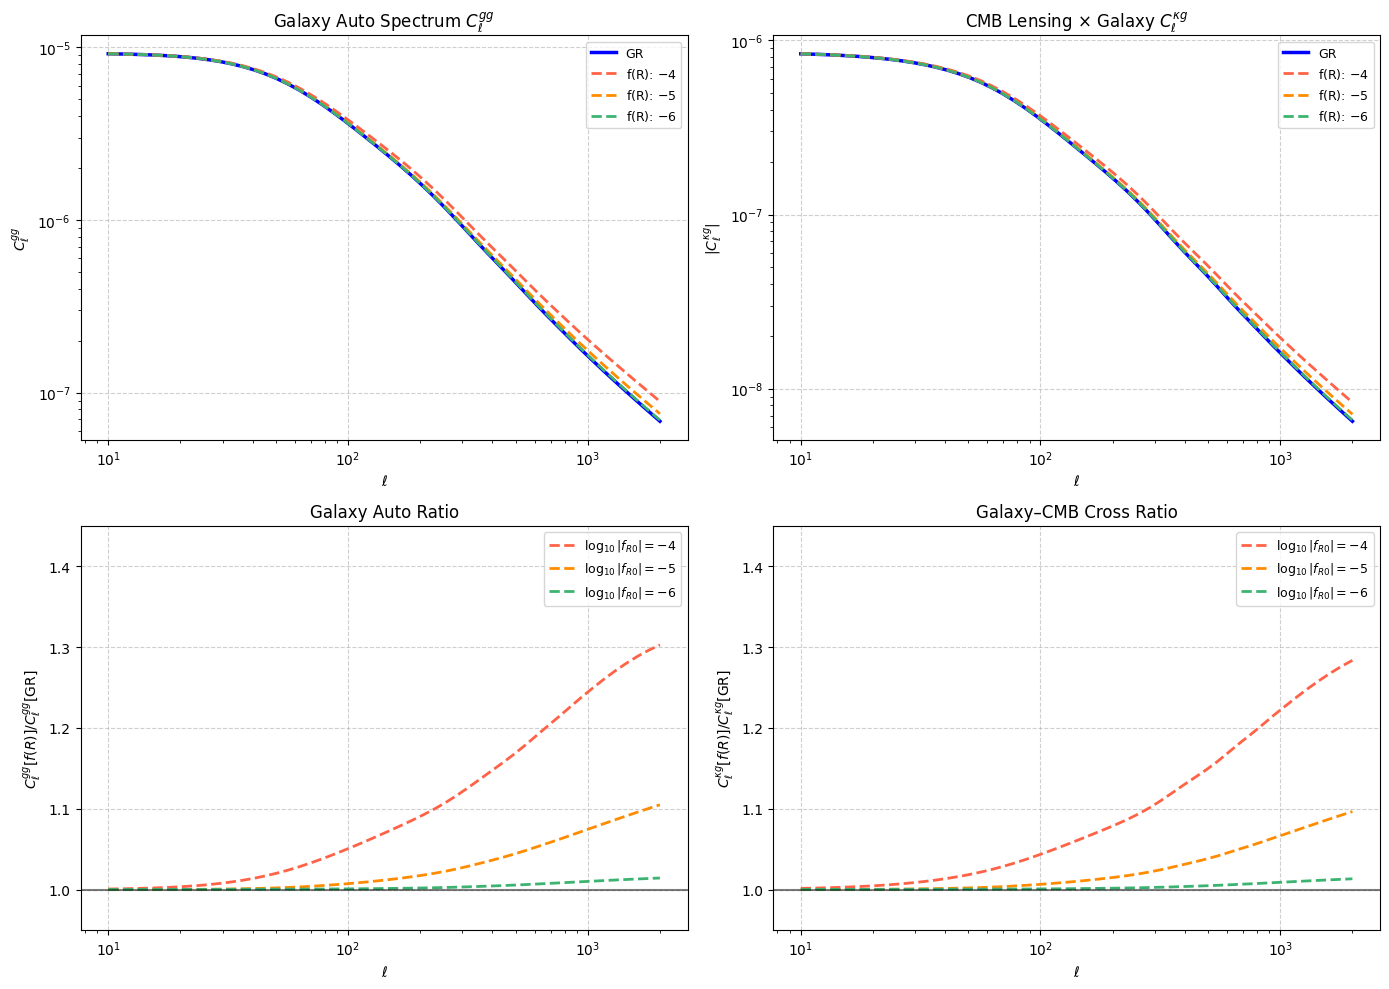

In [16]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None,
                       fR_values=None, figsize=(14, 10)):
    """2×2 panel: C_ℓ^gg, C_ℓ^κg, and their f(R)/GR ratios."""
    colors = ['tomato', 'darkorange', 'mediumseagreen']
    fig = plt.figure(figsize=figsize)

    # ── C_ℓ^{gg} ─────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.loglog(ell, Cl_gg_gr, 'b-', lw=2.5, label=r'GR')
    if fr_results and fR_values:
        for fv, col in zip(fR_values, colors):
            if fv in fr_results["gg"]:
                ax1.loglog(ell, fr_results["gg"][fv], '--', lw=2, color=col,
                           label=rf'f(R): $-{fv}$')
    ax1.set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$',
            title=r'Galaxy Auto Spectrum $C_\ell^{gg}$')
    ax1.legend(fontsize=9); ax1.grid(True, ls='--', alpha=0.6)

    # ── C_ℓ^{κg} ─────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.loglog(ell, np.abs(Cl_kg_gr), 'b-', lw=2.5, label=r'GR')
    if fr_results and fR_values:
        for fv, col in zip(fR_values, colors):
            if fv in fr_results["kg"]:
                ax2.loglog(ell, np.abs(fr_results["kg"][fv]), '--', lw=2, color=col,
                           label=rf'f(R): $-{fv}$')
    ax2.set(xlabel=r'$\ell$', ylabel=r'$|C_\ell^{\kappa g}|$',
            title=r'CMB Lensing × Galaxy $C_\ell^{\kappa g}$')
    ax2.legend(fontsize=9); ax2.grid(True, ls='--', alpha=0.6)

    # ── Ratio C_ℓ^{gg} ────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(2, 2, 3)
    if fr_results and fR_values:
        for fv, col in zip(fR_values, colors):
            if fv in fr_results["gg"]:
                ax3.semilogx(ell, fr_results["gg"][fv] / Cl_gg_gr, '--', lw=2,
                             color=col, label=rf'$\log_{{10}}|f_{{R0}}|=-{fv}$')
    ax3.axhline(1.0, color='k', lw=1.5, alpha=0.5)
    ax3.set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}[f(R)]/C_\ell^{gg}[\mathrm{GR}]$',
            title='Galaxy Auto Ratio', ylim=[0.95, 1.45])
    ax3.legend(fontsize=9); ax3.grid(True, ls='--', alpha=0.6)

    # ── Ratio C_ℓ^{κg} ───────────────────────────────────────────────────────
    ax4 = fig.add_subplot(2, 2, 4)
    if fr_results and fR_values:
        for fv, col in zip(fR_values, colors):
            if fv in fr_results["kg"]:
                ax4.semilogx(ell, fr_results["kg"][fv] / Cl_kg_gr, '--', lw=2,
                             color=col, label=rf'$\log_{{10}}|f_{{R0}}|=-{fv}$')
    ax4.axhline(1.0, color='k', lw=1.5, alpha=0.5)
    ax4.set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{\kappa g}[f(R)]/C_\ell^{\kappa g}[\mathrm{GR}]$',
            title='Galaxy–CMB Cross Ratio', ylim=[0.95, 1.45])
    ax4.legend(fontsize=9); ax4.grid(True, ls='--', alpha=0.6)

    plt.tight_layout()
    return fig


fig = plot_power_spectra(
    ell, Cl_gg_gr, Cl_kg_gr,
    fr_results=fr_results,
    fR_values=Config.FR_VALUES,
    figsize=Config.FIGURE_SIZE
)
plt.show()


## 11. Validation — Assertions & Sanity Checks

Systematic checks on all outputs.  A final success message is printed if every assertion passes.


In [17]:
print("=" * 60)
print("VALIDATION SUITE")
print("=" * 60)
failures = []

def check(condition, msg):
    if condition:
        print(f"  ✓  {msg}")
    else:
        failures.append(msg)
        print(f"  ✗  FAIL: {msg}")

# ── 1. n(z) normalisation ──────────────────────────────────────────────────────
norm_val = simpson(dNdz, z_grid)
check(abs(norm_val - 1.0) < 1e-4, f"n(z) normalised to 1 (got {norm_val:.6f})")

# ── 2. D(z=0) ≈ 1 ─────────────────────────────────────────────────────────────
D_at_zero = growth_factor_D(1e-4, H0, Om_m, Om_lambda)
check(abs(D_at_zero - 1.0) < 0.01, f"D(z→0) ≈ 1 (got {D_at_zero:.5f})")

# ── 3. D(z) decreasing ────────────────────────────────────────────────────────
check(np.all(np.diff(D_vals) <= 0), "D(z) monotonically decreasing with z")

# ── 4. χ(z) increasing ────────────────────────────────────────────────────────
check(np.all(np.diff(chi_vals) > 0), "χ(z) monotonically increasing with z")

# ── 5. CMB lensing kernel positive ────────────────────────────────────────────
check(np.all(Wkappa_vals >= 0), "W_κ(z) ≥ 0 everywhere")

# ── 6. C_ℓ^{gg} positive ──────────────────────────────────────────────────────
check(np.all(Cl_gg_gr > 0), "C_ℓ^{gg} [GR] > 0 for all ℓ")
check(np.all(Cl_gg_gr < 1e3), "C_ℓ^{gg} [GR] < 1e3 (not wildly large)")

# ── 7. C_ℓ^{κg} positive ─────────────────────────────────────────────────────
check(np.all(Cl_kg_gr > 0), "C_ℓ^{κg} [GR] > 0 for all ℓ")

# ── 8. C_ℓ decreasing broadly with ℓ ──────────────────────────────────────────
# Compare median of first half vs second half of ℓ range
n_half = Config.N_ELL // 2
check(np.median(Cl_gg_gr[:n_half]) > np.median(Cl_gg_gr[n_half:]),
      "C_ℓ^{gg} [GR] broadly decreasing with ℓ")
check(np.median(Cl_kg_gr[:n_half]) > np.median(Cl_kg_gr[n_half:]),
      "C_ℓ^{κg} [GR] broadly decreasing with ℓ")

# ── 9. f(R) boosts power relative to GR ───────────────────────────────────────
for fv in Config.FR_VALUES:
    ratio_gg = fr_results["gg"][fv] / Cl_gg_gr
    ratio_kg = fr_results["kg"][fv] / Cl_kg_gr
    check(np.all(ratio_gg >= 1.0 - 1e-3),
          f"C_ℓ^{{gg}} f(R) log|fR0|=-{fv}: ratio ≥ 1 (min={ratio_gg.min():.4f})")
    check(np.all(ratio_kg >= 1.0 - 1e-3),
          f"C_ℓ^{{κg}} f(R) log|fR0|=-{fv}: ratio ≥ 1 (min={ratio_kg.min():.4f})")

# ── 10. Stronger gravity → larger boost ───────────────────────────────────────
# |fR0| = 10^{-4} > 10^{-5} > 10^{-6}, so sorted ascending by FR_VALUES → biggest last?
# Actually larger logfR0 (e.g. 6) means weaker modification; smaller (4) means stronger.
# Expect FR4 > FR5 > FR6 at high ℓ
mid_ell_idx = Config.N_ELL // 2
if len(Config.FR_VALUES) >= 2:
    fv_strong = min(Config.FR_VALUES)
    fv_weak   = max(Config.FR_VALUES)
    ratio_strong = fr_results["gg"][fv_strong][mid_ell_idx] / Cl_gg_gr[mid_ell_idx]
    ratio_weak   = fr_results["gg"][fv_weak][mid_ell_idx]   / Cl_gg_gr[mid_ell_idx]
    check(ratio_strong >= ratio_weak,
          f"Stronger f(R) (log|fR0|=-{fv_strong}) boosts more than weaker (log|fR0|=-{fv_weak})")

# ── 11. P(k) interpolator round-trip ─────────────────────────────────────────
pk_test = get_bacco_nonlinear_pk(bacco_emu, Config.COSMO_PARAMS, k, aexp=1.0)
interp_test = create_power_spectrum_interpolator(k, pk_test)
log_k_mid = np.log(k[len(k)//2])
P_orig = pk_test[len(k)//2]
P_interp = np.exp(interp_test(log_k_mid))
rel_err = abs(P_interp - P_orig) / P_orig
check(rel_err < 1e-4, f"P(k) interpolator round-trip error < 0.01% (got {rel_err:.2e})")

# ── 12. ℓ grid correct length ────────────────────────────────────────────────
check(len(ell) == Config.N_ELL, f"ℓ grid has {Config.N_ELL} points (got {len(ell)})")

print()
print("=" * 60)
if failures:
    print(f"RESULT: {len(failures)} check(s) FAILED:")
    for f in failures:
        print(f"   • {f}")
else:
    print("✅  ALL VALIDATION CHECKS PASSED SUCCESSFULLY!")
    print()
    print("Summary of computed spectra:")
    print(f"  GR  C_ℓ^{{gg}}  @ ℓ=100 : {Cl_gg_gr[np.argmin(np.abs(ell-100))]:.4e}")
    print(f"  GR  C_ℓ^{{κg}} @ ℓ=100 : {Cl_kg_gr[np.argmin(np.abs(ell-100))]:.4e}")
    for fv in Config.FR_VALUES:
        idx = np.argmin(np.abs(ell - 100))
        r_gg = fr_results["gg"][fv][idx] / Cl_gg_gr[idx]
        r_kg = fr_results["kg"][fv][idx] / Cl_kg_gr[idx]
        print(f"  f(R) log|fR0|=-{fv}  ratio C_gg={r_gg:.4f},  ratio C_kg={r_kg:.4f}")
print("=" * 60)


VALIDATION SUITE
  ✓  n(z) normalised to 1 (got 1.000000)
  ✓  D(z→0) ≈ 1 (got 0.99995)
  ✓  D(z) monotonically decreasing with z
  ✓  χ(z) monotonically increasing with z
  ✓  W_κ(z) ≥ 0 everywhere
  ✓  C_ℓ^{gg} [GR] > 0 for all ℓ
  ✓  C_ℓ^{gg} [GR] < 1e3 (not wildly large)
  ✓  C_ℓ^{κg} [GR] > 0 for all ℓ
  ✓  C_ℓ^{gg} [GR] broadly decreasing with ℓ
  ✓  C_ℓ^{κg} [GR] broadly decreasing with ℓ
  ✓  C_ℓ^{gg} f(R) log|fR0|=-4: ratio ≥ 1 (min=1.0008)
  ✓  C_ℓ^{κg} f(R) log|fR0|=-4: ratio ≥ 1 (min=1.0016)
  ✓  C_ℓ^{gg} f(R) log|fR0|=-5: ratio ≥ 1 (min=1.0001)
  ✓  C_ℓ^{κg} f(R) log|fR0|=-5: ratio ≥ 1 (min=1.0002)
  ✓  C_ℓ^{gg} f(R) log|fR0|=-6: ratio ≥ 1 (min=1.0002)
  ✓  C_ℓ^{κg} f(R) log|fR0|=-6: ratio ≥ 1 (min=1.0003)
  ✓  Stronger f(R) (log|fR0|=-4) boosts more than weaker (log|fR0|=-6)
  ✓  P(k) interpolator round-trip error < 0.01% (got 6.64e-16)
  ✓  ℓ grid has 50 points (got 50)

✅  ALL VALIDATION CHECKS PASSED SUCCESSFULLY!

Summary of computed spectra:
  GR  C_ℓ^{gg}  @ ℓ=100 :